In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# load the built in 'titanic ' dataset
df=sns.load_dataset('titanic')

# colomns : survived	pclass	sex	age	sibsp	parch	fare	embarked	class	who	adult_male	deck	embark_town	alive	alone 
sns.set_theme(style='whitegrid',palette='deep',font_scale=0.95)

df
# set a global theme once =affects every plot dramn afterward

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


#### Scatter plot  

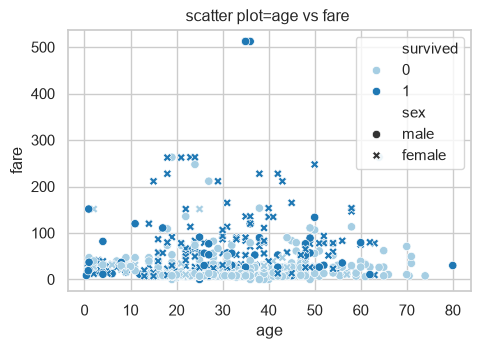

In [15]:
plt.figure(figsize=(5.2,3.4))
sns.scatterplot(data=df,x='age',y='fare',hue='survived',style='sex',palette='Paired')
plt.title("scatter plot=age vs fare ")
plt.xlabel("age")
plt.ylabel("fare")

plt.show()

<Axes: >

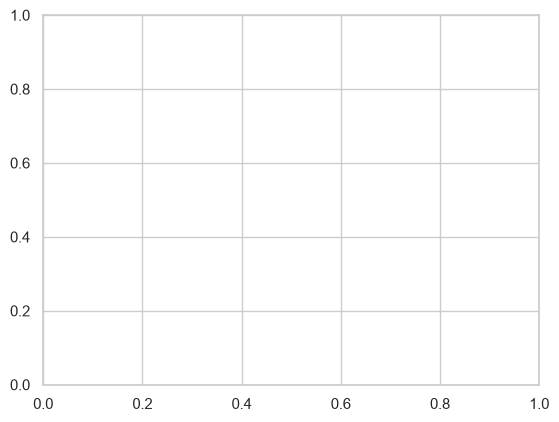

In [16]:
sns.countplot()


In [17]:
import seaborn as sns

print(sns.palettes.SEABORN_PALETTES.keys())

dict_keys(['deep', 'deep6', 'muted', 'muted6', 'pastel', 'pastel6', 'bright', 'bright6', 'dark', 'dark6', 'colorblind', 'colorblind6'])


### Line plot

<Axes: xlabel='age_mid', ylabel='survived'>

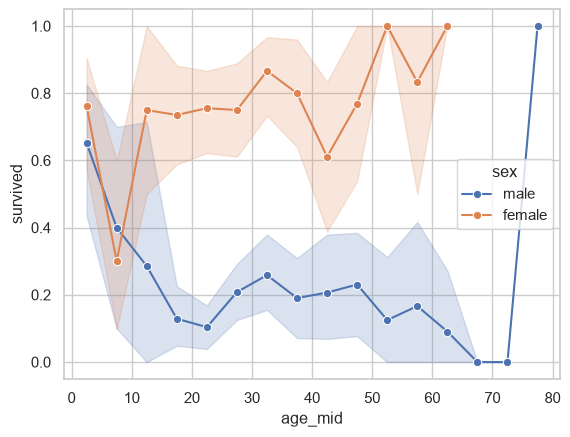

In [26]:
df['age_group']=pd.cut(df['age'],bins=range(0,85,5))
tmp=(df.dropna(subset=['age_group']).assign(age_mid=lambda x:x['age_group'].map(lambda i:i.mid)))
sns.lineplot(data=tmp,x='age_mid',y='survived',hue='sex',marker='o',errorbar=('ci',95))


<Axes: xlabel='fare_mid', ylabel='survived'>

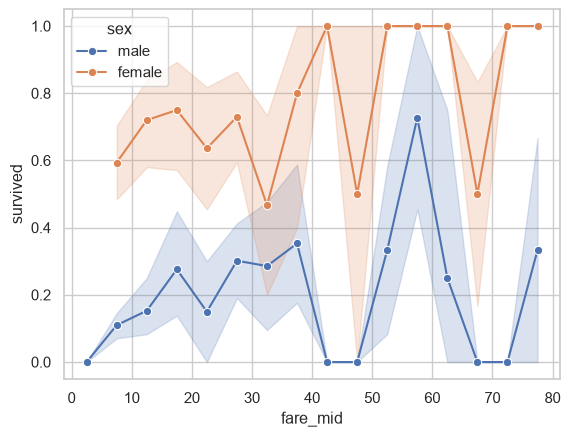

In [27]:
df['fare_group']=pd.cut(df['fare'],bins=range(0,85,5))
tmp=(df.dropna(subset=['fare_group']).assign(fare_mid=lambda x:x['fare_group'].map(lambda i:i.mid)))
sns.lineplot(data=tmp,x='fare_mid',y='survived',hue='sex',marker='o',errorbar=('ci',95))


## Histplot

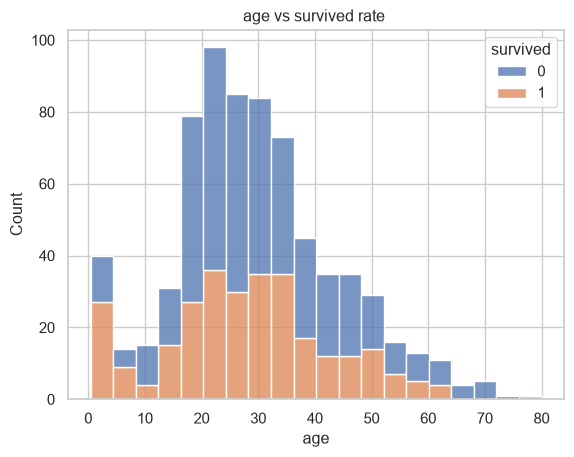

In [32]:
sns.histplot(data=df,x='age',hue='survived',multiple='stack')
plt.title('age vs survived rate ')
plt.show()

## Kdeplot

Text(0.5, 1.0, 'fare vs class')

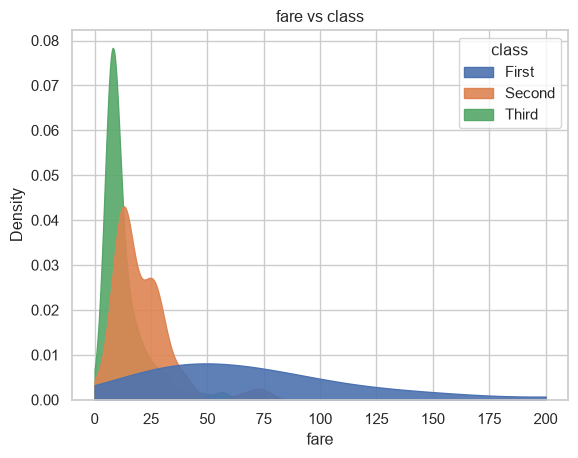

In [45]:
sns.kdeplot(data=df,x='fare',hue='class',fill=True , common_norm=False ,
            alpha=0.9
            ,clip=(0,200))
plt.title("fare vs class")

## Rugplot

Text(0.5, 1.0, 'fare vs class')

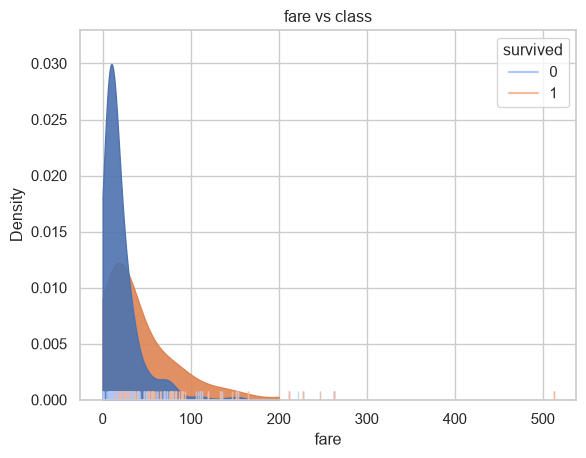

In [52]:
sns.kdeplot(data=df,x='fare',hue='survived',fill=True , common_norm=False ,
            alpha=0.9
            ,clip=(0,200))
sns.rugplot(data=df,x='fare',hue='survived',palette='coolwarm',alpha=0.7)
plt.title("fare vs class")

## Box and violion plot

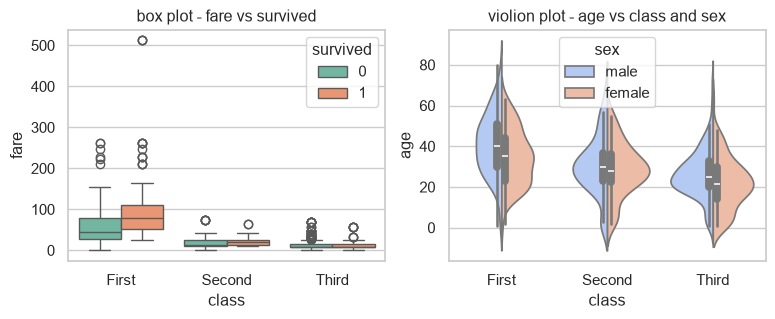

In [62]:
fig,ax=plt.subplots(1,2,figsize=(9,3))
sns.boxplot(data=df, x='class',
            y='fare',
            hue='survived',
            palette='Set2',
            ax=ax[0])
ax[0].set_title("box plot - fare vs survived")
sns.violinplot(data=df, x='class',
            y='age',
            hue='sex',
            split=True,
            palette='coolwarm',
            ax=ax[1])
ax[1].set_title("violion plot - age vs class and sex")

plt.show()

##  heatmap plot 

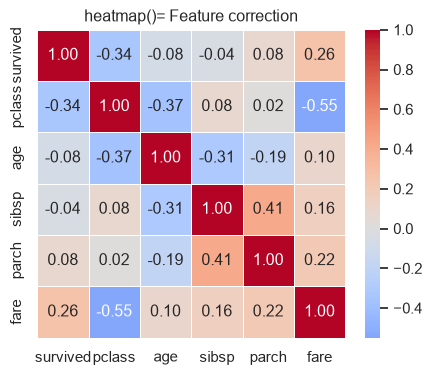

In [64]:
numeric_cols=['survived','pclass','age','sibsp','parch','fare']
corr=df[numeric_cols].corr()
plt.figure(figsize=(5,4))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True
)
plt.title('heatmap()= Feature correction')
plt.show()